<a href="https://colab.research.google.com/github/lotus-mm/CS61B-Tutorial/blob/main/Clau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ──────────────────────────────────────────────────────────────────
# CELL 1 — 导入库与项目初始化 / Imports & project setup
# ──────────────────────────────────────────────────────────────────
import os, sys, warnings
warnings.filterwarnings("ignore")  # 屏蔽不必要的警告信息

import ee, geemap
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

# 在Notebook环境中用getcwd()替代__file__来定位项目根目录
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)
os.makedirs("outputs", exist_ok=True)       # 创建输出目录
os.makedirs("outputs/shap", exist_ok=True)  # SHAP分析输出子目录

# 挂载Google Drive（在Colab中取消注释）
# from google.colab import drive
# drive.mount("/content/drive")

print("✅ 依赖导入完成 / Dependencies loaded.")


✅ 依赖导入完成 / Dependencies loaded.


In [2]:
# ──────────────────────────────────────────────────────────────────
# CELL 2 — Module 1: 研究区域 / Study region
# ──────────────────────────────────────────────────────────────────
from modules.region01.region import initialize_ee, get_study_region, visualize_region

# 初始化GEE（需要已通过earthengine authenticate认证）
initialize_ee()
# 获取Story County边界（几何体和Feature对象）
geometry, story_county = get_study_region()

print("\n--- Map 1: 研究区域边界 / Study Region Boundary ---")
Map1 = visualize_region(geometry, story_county)
Map1  # 在Notebook中显示交互式地图

✅ Earth Engine 认证并初始化成功
📍 研究区域：Story County, Iowa, USA
   州 FIPS   : 19 (Iowa)
   县 FIPS   : 169 (Story County)
   研究作物  : 玉米 (Corn/Maize)
   面积      : 1483.5 km²
   经度范围  : -93.6988° ~ -93.2314°
   纬度范围  : 41.8626° ~ 42.2094°

--- Map 1: 研究区域边界 / Study Region Boundary ---

🗺️  地图图层说明：
   - 卫星底图 (SATELLITE)
   - 红色实线：Story County 行政边界
   - 半透明黄色：研究区域填充

   ➡ 在 Colab 中执行后，地图将在单元格下方交互展示。


Map(center=[42.0, -93.57], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [3]:
# ──────────────────────────────────────────────────────────────────
# CELL 3 — Module 2A: AlphaEarth 卫星嵌入
#           AlphaEarth satellite embeddings
# ──────────────────────────────────────────────────────────────────
from modules.data02.satellite_embeddings import (
    load_all_embeddings, visualize_embeddings
)
# 加载所有年份的64维卫星嵌入向量
embeddings = load_all_embeddings(geometry)

print("\n--- Map 2: AlphaEarth嵌入 RGB伪彩色 2022 ---")
# 将64维嵌入降维到RGB三通道可视化
Map2 = visualize_embeddings(geometry, story_county, year=2022)
Map2


Loading AlphaEarth embeddings (GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL)...
   [2017] AlphaEarth embedding: 64 bands | CRS: EPSG:32615
   [2018] AlphaEarth embedding: 64 bands | CRS: EPSG:32615
   [2019] AlphaEarth embedding: 64 bands | CRS: EPSG:32615
   [2020] AlphaEarth embedding: 64 bands | CRS: EPSG:32615
   [2021] AlphaEarth embedding: 64 bands | CRS: EPSG:32615
   [2022] AlphaEarth embedding: 64 bands | CRS: EPSG:32615
Done — 6 years: [2017, 2018, 2019, 2020, 2021, 2022]

--- Map 2: AlphaEarth嵌入 RGB伪彩色 2022 ---
   [2022] AlphaEarth embedding: 64 bands | CRS: EPSG:32615

AlphaEarth embedding map (2022) — RGB legend added:
  R → A00  |  G → A01  |  B → A02
  Contrast stretch: p2–p98 percentile within county


Map(center=[42.0, -93.57], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [4]:
# ──────────────────────────────────────────────────────────────────
# CELL 4 — Module 2B: ERA5气象数据（含图例）
#           ERA5-Land weather data (with colorbar legend)
# ──────────────────────────────────────────────────────────────────
from modules.data02.weather_data import load_all_weather, visualize_weather

# 加载生长季（4-9月）气象数据：降水量、均温、最高温
weather_data = load_all_weather(geometry)

print("\n--- Map 3: 生长季气象（自适应色彩+图例）---")
# [v3改进] 1km双线性重采样+p2/p98自适应色带+图例
Map3 = visualize_weather(geometry, story_county, year=2022)
Map3


Loading ERA5-Land weather data (ECMWF/ERA5_LAND/MONTHLY_AGGR)...
  Growing season months: [4, 5, 6, 7, 8, 9]
   [2017] precip=509.7 mm | tmean=19.44 C | tmax=30.99 C
   [2018] precip=861.5 mm | tmean=18.88 C | tmax=31.91 C
   [2019] precip=753.8 mm | tmean=19.06 C | tmax=30.97 C
   [2020] precip=479.4 mm | tmean=18.88 C | tmax=31.34 C
   [2021] precip=482.7 mm | tmean=19.89 C | tmax=32.21 C
   [2022] precip=560.6 mm | tmean=18.89 C | tmax=31.92 C
Done -- 6 years loaded: [2017, 2018, 2019, 2020, 2021, 2022]

--- Map 3: 生长季气象（自适应色彩+图例）---
   [2022] precip=560.6 mm | tmean=18.89 C | tmax=31.92 C

Weather visualization (2022 growing season):
  Layer 1 -- Cumulative precipitation  [544.1, 572.2] mm
  Layer 2 -- Mean temperature           [17.66, 20.05] C
  Layer 3 -- Mean max temperature       [30.82, 33.23] C
  [v3] Colour bar legends added to each layer.
  Display scale: 1000 m (bilinear resampled from ERA5 ~9 km)


Map(center=[42.0, -93.57], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [5]:
# ──────────────────────────────────────────────────────────────────
# CELL 5 — Module 2C: 土壤数据（含图例）
#           Soil data (with colorbar legend)
# ──────────────────────────────────────────────────────────────────
from modules.data02.soil_data import load_soil_data, visualize_soil

# 加载土壤有机碳/pH/沙粒含量（0-5cm表层）
soil_data = load_soil_data(geometry)

print("\n--- Map 4: 土壤属性（250m分辨率+图例）---")
# [v3改进] 250m原生分辨率+p2/p98自适应色带+图例
Map4 = visualize_soil(geometry, story_county)
Map4


Loading OpenLandMap soil data...
  Story County soil statistics (surface 0-5 cm):
    SOC  : 3.36 g/kg
    pH   : 6.337
    Sand : 33.2 %
Done -- soil data loaded.

--- Map 4: 土壤属性（250m分辨率+图例）---
Loading OpenLandMap soil data...
  Story County soil statistics (surface 0-5 cm):
    SOC  : 3.36 g/kg
    pH   : 6.337
    Sand : 33.2 %
Done -- soil data loaded.

Soil visualization layers (250 m, p2-p98 adaptive stretch):
  Layer 1 -- SOC  (g/kg) : [2.0, 5.0]
  Layer 2 -- pH          : [5.90, 6.70]
  Layer 3 -- Sand (%)    : [20.0, 44.0]
  [v3] Colour bar legends added to each layer.


Map(center=[42.0, -93.57], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [6]:
# ──────────────────────────────────────────────────────────────────
# CELL 6 — Module 2D: USDA NASS CDL 玉米掩膜
#           Corn crop mask
# ──────────────────────────────────────────────────────────────────
from modules.data02.crop_mask import load_all_corn_masks, visualize_crop_mask

# 基于CDL（作物数据层）提取玉米种植区域
corn_masks = load_all_corn_masks(geometry)

print("\n--- Map 5: 玉米种植掩膜 (2022, CDL) ---")
Map5 = visualize_crop_mask(geometry, story_county, year=2022)
Map5


🌽 正在加载 USDA NASS CDL 玉米种植掩膜...
   [2017] 玉米种植像元数：744,087.9764705884 | 估算面积：66,968 公顷
   [2018] 玉米种植像元数：718,426.1764705882 | 估算面积：64,658 公顷
   [2019] 玉米种植像元数：771,731.4235294119 | 估算面积：69,456 公顷
   [2020] 玉米种植像元数：767,305.7098039215 | 估算面积：69,058 公顷
   [2021] 玉米种植像元数：643,036.9137254902 | 估算面积：57,873 公顷
   [2022] 玉米种植像元数：705,409.8470588236 | 估算面积：63,487 公顷
✅ 玉米掩膜加载完成：[2017, 2018, 2019, 2020, 2021, 2022]

--- Map 5: 玉米种植掩膜 (2022, CDL) ---
   [2022] 玉米种植像元数：705,409.8470588236 | 估算面积：63,487 公顷

🌽 玉米掩膜可视化（2022年）：
   - 黄色区域：玉米种植像元（CDL 像元值=1）
   - 红色边界：Story County 行政边界
   - 底图：卫星影像 (SATELLITE)


Map(center=[42.0, -93.57], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [7]:
# ──────────────────────────────────────────────────────────────────
# CELL 7 — Module 3: 特征提取与样本构建
#           Feature extraction & training sample construction
# ──────────────────────────────────────────────────────────────────
from modules.features03.feature_extraction import build_all_training_samples

# 构建全年份训练样本：每年采样500个玉米像素
# 特征 = 64维AlphaEarth嵌入 + 3维气象 + 3维土壤 = 70维
# 标签 = 该年USDA县均产量
training_fc, feature_names = build_all_training_samples(geometry)

print(f"\n特征维度 / Feature dims  : {len(feature_names)}")
print(f"训练样本数 / Training samples: {training_fc.size().getInfo()}")
print(f"特征示例 / Features (first 5): {feature_names[:5]}")
print(f"特征示例 / Features (last 3) : {feature_names[-3:]}")


📊 特征工程：构建多源训练样本集

── 处理 2017 年 ──
   [2017] AlphaEarth embedding: 64 bands | CRS: EPSG:32615
   [2017] precip=509.7 mm | tmean=19.44 C | tmax=30.99 C
Loading OpenLandMap soil data...
  Story County soil statistics (surface 0-5 cm):
    SOC  : 3.36 g/kg
    pH   : 6.337
    Sand : 33.2 %
Done -- soil data loaded.
   [2017] 特征栈构建完成 | 总波段数: 70
         嵌入64维 + 气象3维(precip/tmean/tmax) + 土壤3维(soc/ph/sand)
   [2017] 玉米种植像元数：744,087.9764705884 | 估算面积：66,968 公顷
   [2017] 采样点数: 253 | 产量标签: 197.5 bu/acre

── 处理 2018 年 ──
   [2018] AlphaEarth embedding: 64 bands | CRS: EPSG:32615
   [2018] precip=861.5 mm | tmean=18.88 C | tmax=31.91 C
Loading OpenLandMap soil data...
  Story County soil statistics (surface 0-5 cm):
    SOC  : 3.36 g/kg
    pH   : 6.337
    Sand : 33.2 %
Done -- soil data loaded.
   [2018] 特征栈构建完成 | 总波段数: 70
         嵌入64维 + 气象3维(precip/tmean/tmax) + 土壤3维(soc/ph/sand)
   [2018] 玉米种植像元数：718,426.1764705882 | 估算面积：64,658 公顷
   [2018] 采样点数: 244 | 产量标签: 195.0 bu/acre

── 处理 2019 年 ──


In [8]:
# ──────────────────────────────────────────────────────────────────
# CELL 8A — Module 4A: 随机森林基线（GEE版）
#            Random Forest baseline (GEE server-side)
# ──────────────────────────────────────────────────────────────────
from modules.model04.train_model import (
    train_random_forest, evaluate_model,
    plot_scatter, get_feature_importance
)

# 在GEE服务器端训练随机森林（用于像素级产量制图）
# 注：这个RF用GEE的SmileRandomForest，只能用于GEE image.classify()
rf_model = train_random_forest(training_fc, feature_names)

# 评估训练集拟合（注意：这是训练集误差，不是泛化误差）
metrics, df_pred = evaluate_model(rf_model, training_fc)
print("\n注意：以下指标是训练集误差，不代表泛化能力！")
print("LOYO-CV指标（见CELL 11）才代表模型对未见年份的预测能力。")


Random Forest Regression — Training
  Trees    : 200
  Features : 70
  Target   : yield_buac (bu/acre)
  Samples  : 1426
Training on GEE server (est. 1-3 min)...
Training complete.

Evaluating: Random Forest
  +──────────────────────────────────────────+
  │ Metric                            Value  │
  +──────────────────────────────────────────+
  │ RMSE (bu/acre)                   0.9789  │
  │ MAE  (bu/acre)                   0.6560  │
  │ MAPE (%)                         0.3479  │
  │ R²                               0.9870  │
  +──────────────────────────────────────────+

注意：以下指标是训练集误差，不代表泛化能力！
LOYO-CV指标（见CELL 11）才代表模型对未见年份的预测能力。


  Saved: outputs/rf_scatter.png


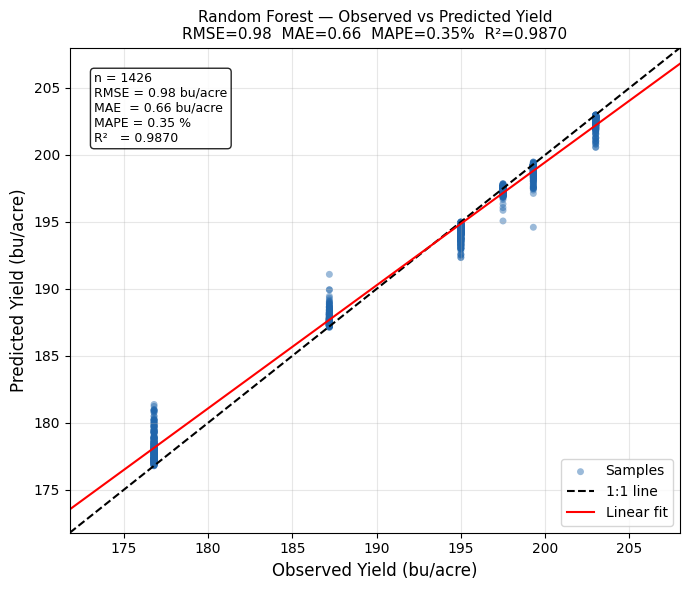

In [9]:
fig_sc  = plot_scatter(df_pred, metrics,
                        save_path="outputs/rf_scatter.png")
plt.show()


Feature Importance — Top 70
   1. [Wx] precip_gs            ████████████████████ 4385056379.1318
   2. [Wx] tmean_gs             ███████████████ 3380275429.4909
   3. [Wx] tmax_gs              ████████████ 2823512953.6910
   4. [Embed] A58                  █████████ 2060057737.2879
   5. [Embed] A13                  █████████ 2002733364.7493
   6. [Embed] A31                  ████████ 1899305958.2523
   7. [Embed] A53                  ████████ 1860644042.1681
   8. [Embed] A23                  ████████ 1825722477.5029
   9. [Embed] A45                  ████████ 1781579318.6583
  10. [Embed] A49                  ███████ 1720681656.8371
  11. [Embed] A10                  ███████ 1672823695.6333
  12. [Embed] A24                  ███████ 1548691273.8229
  13. [Embed] A47                  ██████ 1515833114.3015
  14. [Embed] A38                  ██████ 1367551284.6810
  15. [Embed] A41                  █████ 1313641778.1306
  16. [Embed] A32                  █████ 1299533290.7018
  17. [E

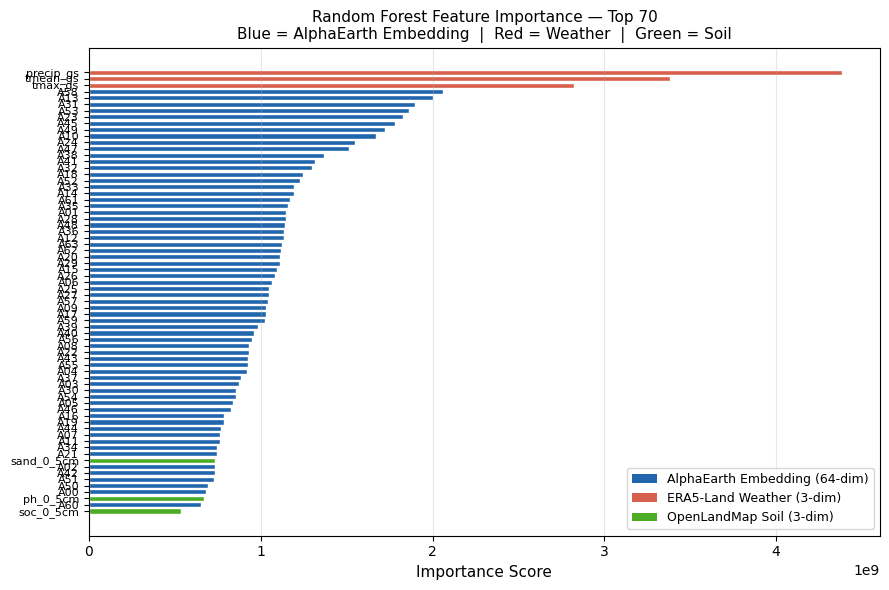

In [10]:
df_imp, fig_imp = get_feature_importance(
    rf_model, feature_names,
    save_path="outputs/rf_feature_importance.png")
plt.show()


In [11]:
# ──────────────────────────────────────────────────────────────────
# CELL 8B — Module 4B: 多模型对比（5折CV）
#            Multi-model comparison (5-fold CV)
# [MODIFIED v4] 新增LinearRegression；RNN/LSTM已注释
# ──────────────────────────────────────────────────────────────────
from modules.model04.multi_model import run_multi_model_comparison

print("""
[v4更新说明]
  - 新增 Linear Regression（多元线性回归）作为最基础基线
  - RNN (GRU) 和 LSTM 已注释掉（数据量不足，效果差，见multi_model.py说明）
  - 深度学习失效根本原因：6年数据对数万参数的循环网络来说远不够
""")



[v4更新说明]
  - 新增 Linear Regression（多元线性回归）作为最基础基线
  - RNN (GRU) 和 LSTM 已注释掉（数据量不足，效果差，见multi_model.py说明）
  - 深度学习失效根本原因：6年数据对数万参数的循环网络来说远不够




[步骤1] 从GEE提取训练样本...
正在从GEE提取样本到pandas DataFrame ...
  提取完成: 1426 个样本 x 72 列

[步骤2] 执行5折交叉验证...
5折交叉验证 | 5-Fold CV  |  设备/device: cuda

── 第1折/5  训练/train=1140  验证/val=286 ──
  Linear Regression    RMSE=2.56  MAE=2.05  MAPE=1.06%  R2=0.9102
  Ridge                RMSE=2.56  MAE=2.05  MAPE=1.06%  R2=0.9102
  SVR                  RMSE=2.24  MAE=1.54  MAPE=0.81%  R2=0.9313
  KNN                  RMSE=1.85  MAE=0.58  MAPE=0.31%  R2=0.9531
  Random Forest        RMSE=0.30  MAE=0.02  MAPE=0.01%  R2=0.9987
  XGBoost              RMSE=0.61  MAE=0.23  MAPE=0.12%  R2=0.9948
  MLP (sklearn)        RMSE=5.49  MAE=4.04  MAPE=2.09%  R2=0.5867
  Stacking             RMSE=3.38  MAE=2.89  MAPE=1.48%  R2=0.8436
  MLP-Deep             RMSE=6.41  MAE=4.75  MAPE=2.50%  R2=0.4375

── 第2折/5  训练/train=1141  验证/val=285 ──
  Linear Regression    RMSE=2.71  MAE=2.13  MAPE=1.11%  R2=0.9056
  Ridge                RMSE=2.71  MAE=2.13  MAPE=1.11%  R2=0.9057
  SVR                  RMSE=2.45  MAE=1.64  MAPE=0.86%  R2=

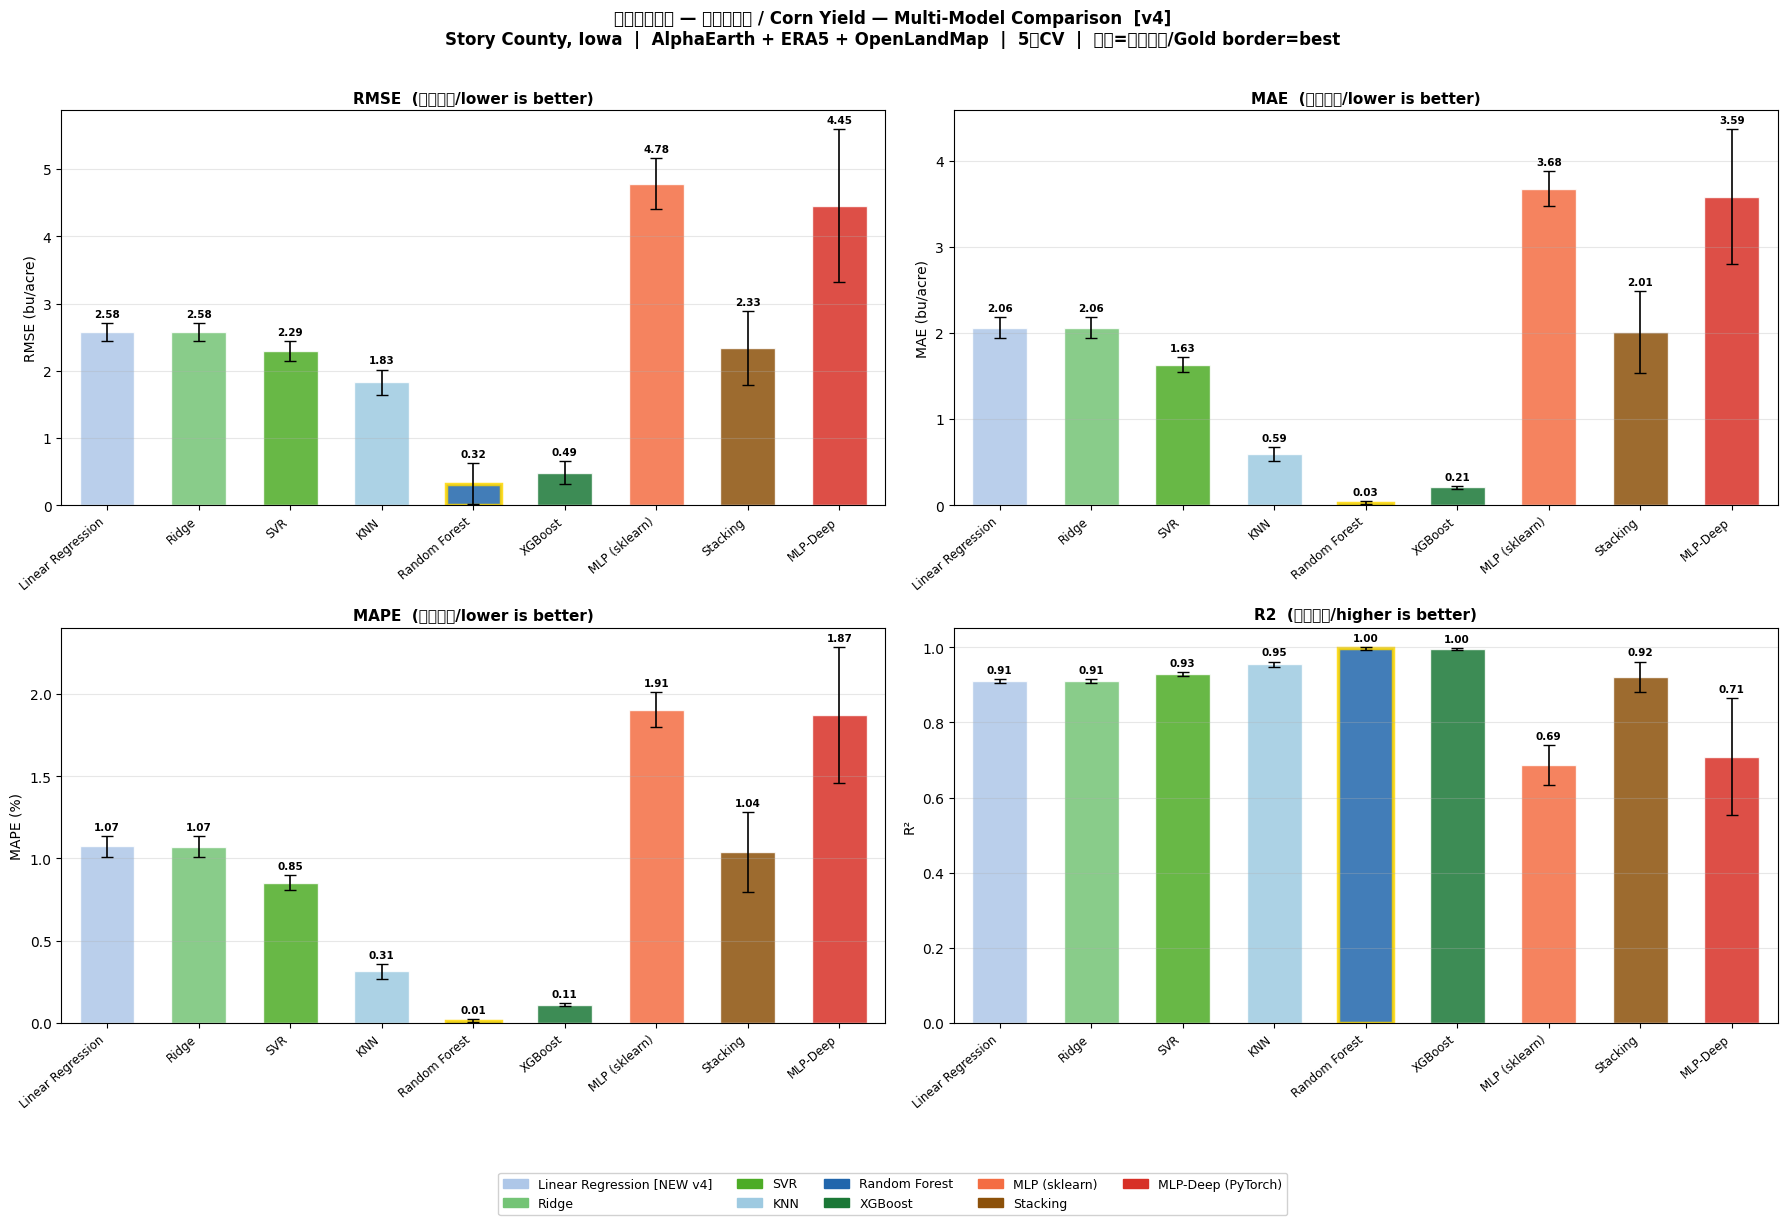

  图片已保存: outputs/multi_model_scatter.png


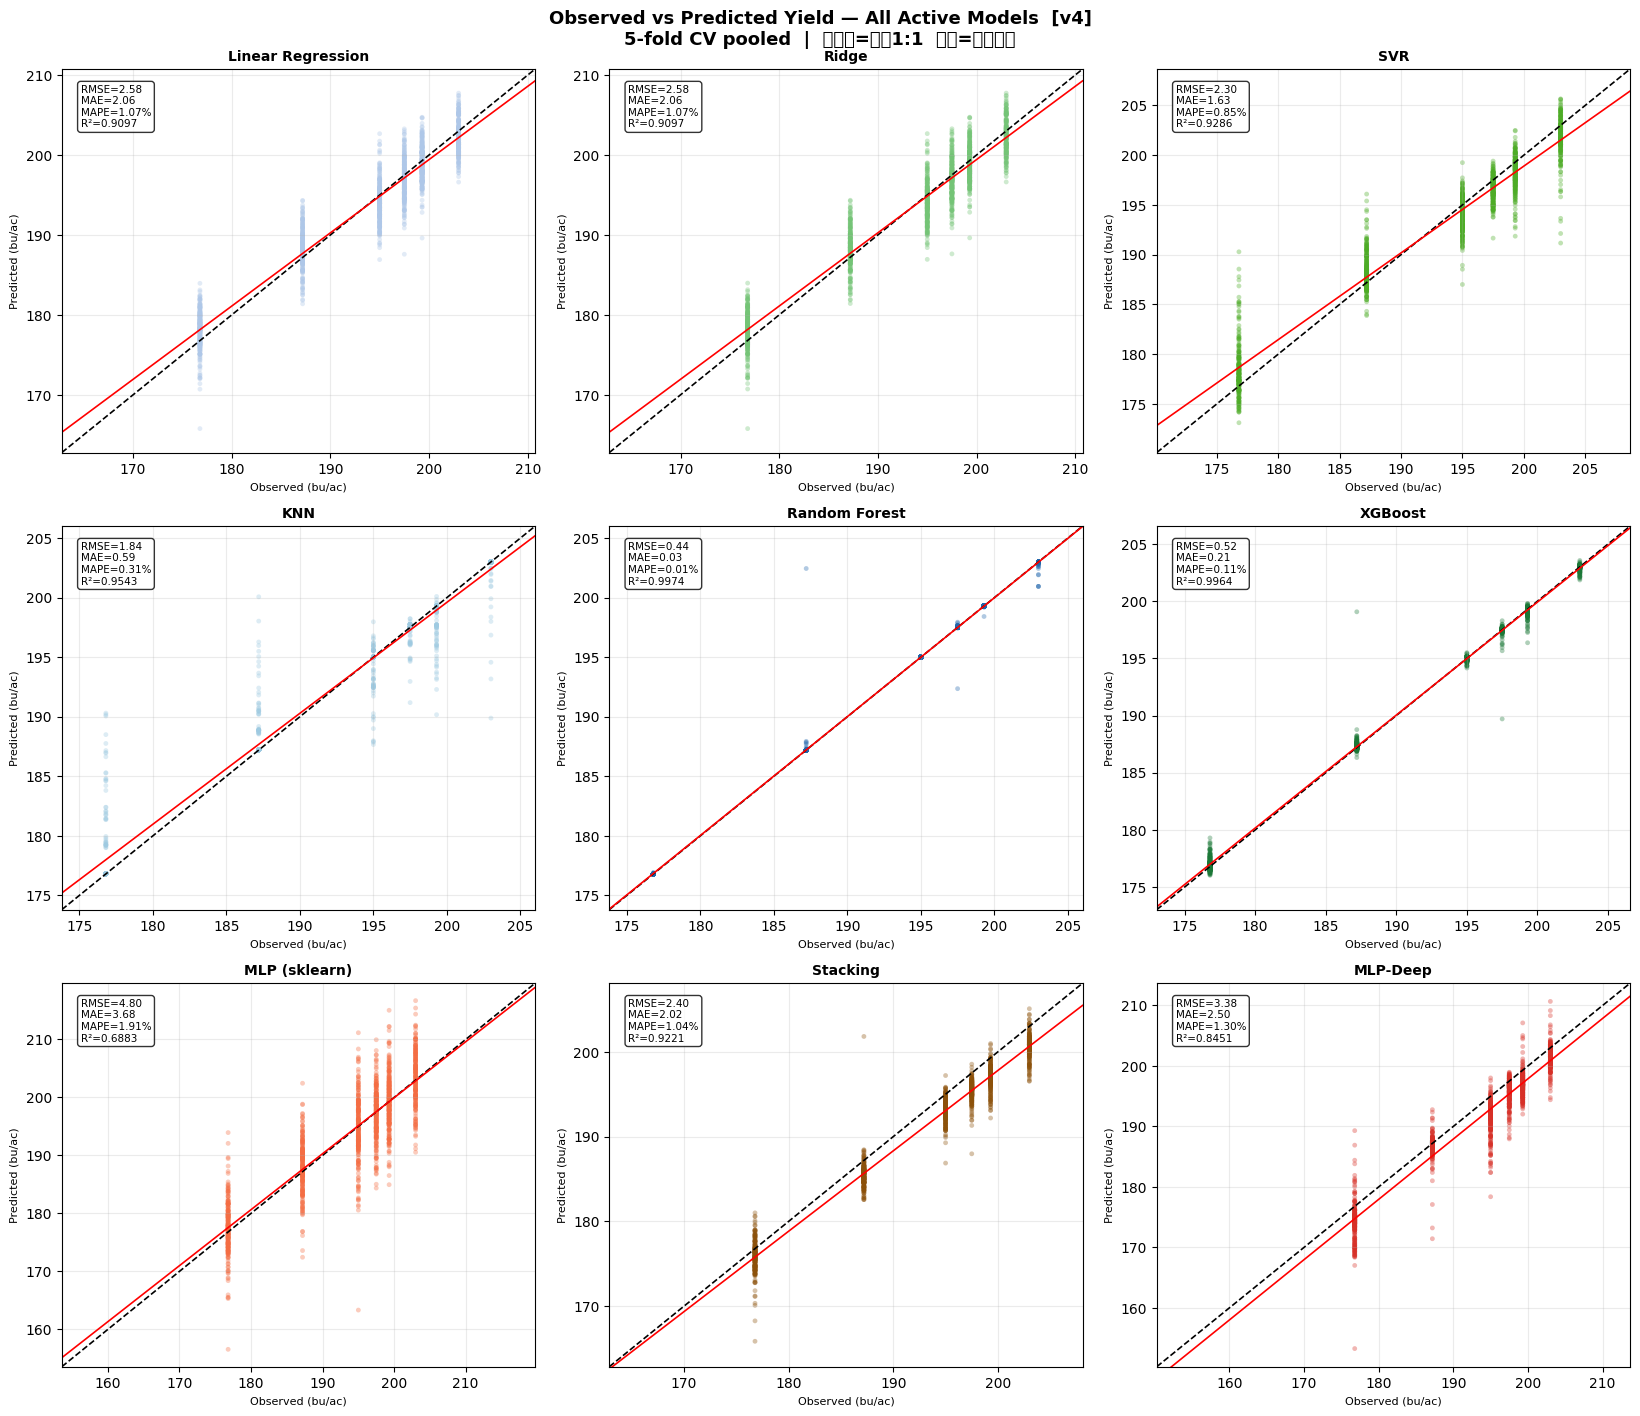

  图片已保存: outputs/multi_model_table.png


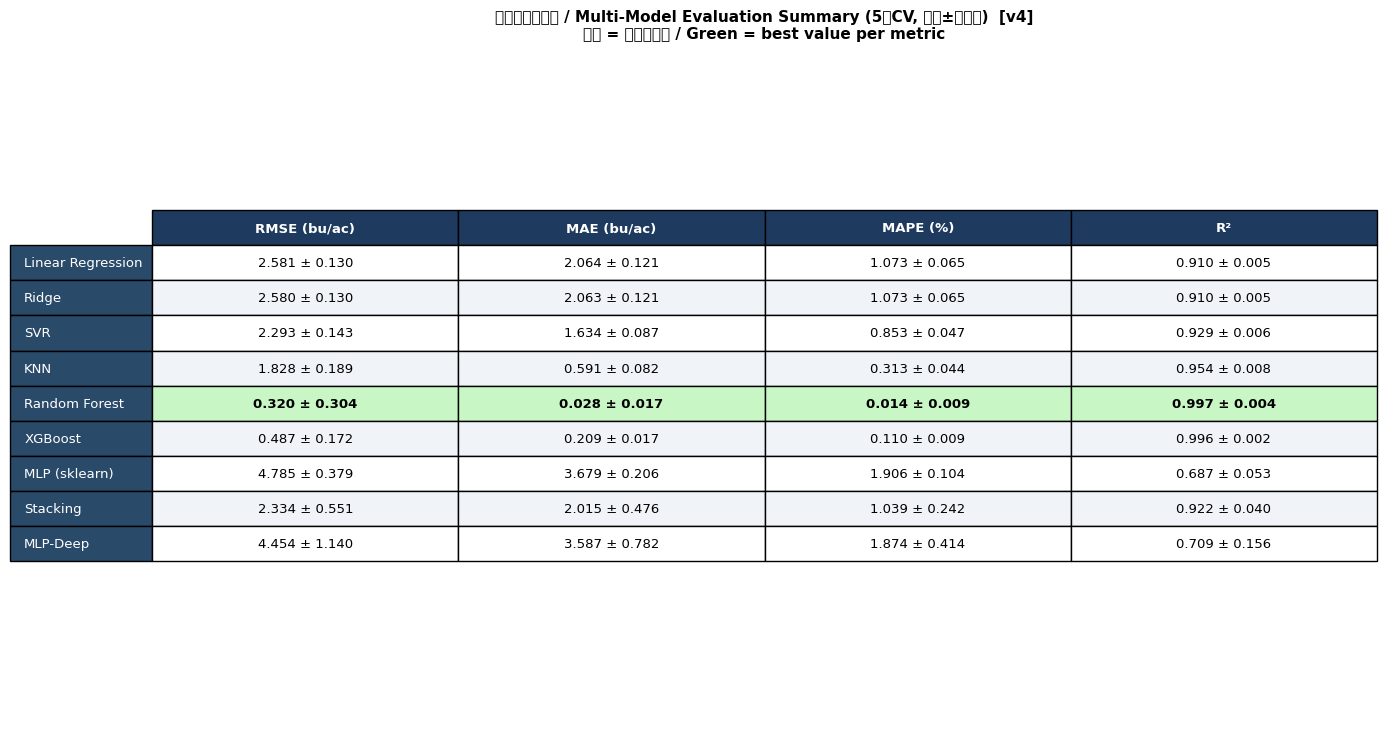

  图片已保存: outputs/multi_model_yield_dist.png


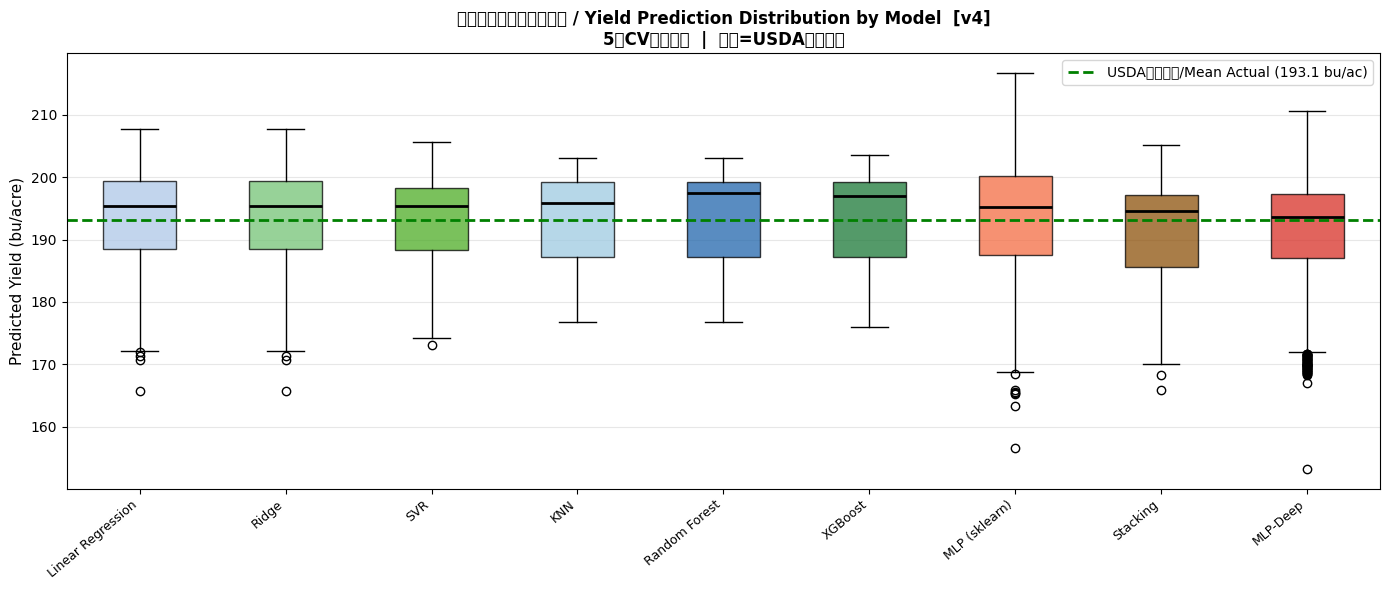

  CSV已保存: outputs/multi_model_summary.csv

5折CV最优模型 / Best model by RMSE: Random Forest


In [12]:
summary_df, best_model, scaler = run_multi_model_comparison(
    training_fc, feature_names,
    output_dir="outputs"
)
print(f"\n5折CV最优模型 / Best model by RMSE: {best_model}")


In [1]:
# ──────────────────────────────────────────────────────────────────
# CELL 8C — Module 4C: SHAP 可解释性分析
#            SHAP explainability analysis
# ──────────────────────────────────────────────────────────────────
from modules.model04.shap_analysis import run_shap_analysis

shap_values, shap_explainer = run_shap_analysis(
    training_fc, feature_names,
    output_dir="outputs"
)

ModuleNotFoundError: No module named 'modules'